In [1]:
import numpy as np
import pandas as pd
import os, re, math, platform
from pathlib import Path
import matplotlib.pyplot as plt
import json
import joblib
from scipy.stats import randint as sp_randint
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, auc, fbeta_score
from imblearn.metrics import geometric_mean_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
from xgboost import plot_importance
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,ExtraTreesClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
from matplotlib import pyplot
from sklearn.metrics import matthews_corrcoef, confusion_matrix,precision_recall_curve, roc_curve, auc, fbeta_score,roc_auc_score
from fea_extract import read_fasta,insert_AAC,insert_DPC,insert_CKSAAGP,insert_CTD,insert_PAAC,insert_AAI,insert_GTPC,insert_QSO,insert_AAE,insert_PSAAC,insert_word2int,insert_ASDC
import warnings 
from tools import cv,evaluate
warnings.filterwarnings('ignore')
seed = 10
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
Path('./results/predict_proba/').mkdir(exist_ok=True,parents=True)
Path('./results/evaluate/').mkdir(exist_ok=True,parents=True)
Path('./results/model/').mkdir(exist_ok=True,parents=True)

In [2]:
GBDT = GradientBoostingClassifier(random_state=seed)
ET = ExtraTreesClassifier(random_state=seed)
SVM = SVC(random_state=seed,probability=True)
MLP = MLPClassifier(hidden_layer_sizes=64,learning_rate="adaptive",random_state=seed)
RF = RandomForestClassifier(random_state=seed)
XGBoost = XGBClassifier(random_state=seed)
LR  = LogisticRegression(random_state=seed)
AB = AdaBoostClassifier(random_state=seed)
clf_feature_order = {
#     "GA": ["XGBoost","RF","ET","GBDT"],
    "Boruta": ["XGBoost","RF","ET"],
#     "Fscore": ["XGBoost","RF","ET","GBDT"],
#     "MI": ["XGBoost","RF","ET","GBDT"],
    "MRMD": ["XGBoost","RF","ET"],
#    "XGB": ["XGBoost","RF","ET","GBDT"],
#     "RFE": ["XGBoost","RF","ET","GBDT"],
}
ml = ["XGBoost","RF","ET","GBDT"]

In [3]:

def base_clf(clf,X_train,y_train,model_name,n_folds=5):
    ntrain = X_train.shape[0]
    nclass = len(np.unique(y_train)) 
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    base_pf_train = np.zeros((ntrain,nclass)) 
    base_cf_train = np.zeros((ntrain))
    
    for train_index, test_index in kf.split(X_train,y_train):
        kf_X_train,kf_y_train = X_train[train_index],y_train[train_index]
        kf_X_test = X_train[test_index]

        clf.fit(kf_X_train, kf_y_train)
        base_pf_train[test_index] = clf.predict_proba(kf_X_test)
        base_cf_train[test_index] = clf.predict(kf_X_test)
    clf.fit(X_train,y_train)
    joblib.dump(model,f'./results/model/{model_name}')
    return base_pf_train[:,-1], base_cf_train

In [4]:
X_train_base_pf = []
X_test_base_pf = []
X_train_base_cf = []
X_test_base_cf = []
X_train_base_pcf = []
X_test_base_pcf = []

all_eval_dic = []
Index = []
index = []
ALL_evals_train = pd.DataFrame()
for (n,m) in clf_feature_order.items():
    X_train = pd.read_csv('Feature_different/X_train_{}.csv'.format(n)).to_numpy()
    X_test = pd.read_csv('Feature_different/X_test_{}.csv'.format(n)).to_numpy()
    y_train = pd.read_csv('data/train/y_train_resampled.csv').to_numpy()
    y_test = pd.read_csv('data/test/y_test.csv').to_numpy()
#     np.random.seed(1234)
#     idx = np.random.permutation(len(X_train))
#     X_train = X_train[idx]
#     y_train = y_train[idx]

    for c in m:
        model = eval(c)
        print("{}_{:s}".format(n,c))
        X_train_pf,X_train_cf = base_clf(model,X_train,y_train,f'{n}_{c}.m')
        Evals = cv(model,X_train,y_train)
        ALL_evals_train = pd.concat([ALL_evals_train,Evals],axis=1)
        index.append('{}_{}'.format(n,c))
                # PF
        X_train_base_pf.append(X_train_pf) 
        X_train_pf_dic = np.array(X_train_base_pf).T
             # CF
        X_train_base_cf.append(X_train_cf) 
        X_train_cf_dic = np.array(X_train_base_cf).T
        # PCF
        X_train_base_pcf.append(X_train_pf)
        X_train_base_pcf.append(X_train_cf)
        X_train_pcf_dic = np.array(X_train_base_pcf).T

        base_model = joblib.load('results/model/{}_{}.m'.format(n,c))
                # PF
        X_test_pf = base_model.predict_proba(X_test)[:,-1]
        X_test_base_pf.append(X_test_pf) 
        X_test_pf_dic = np.array(X_test_base_pf).T
                # CF
        X_test_cf = base_model.predict(X_test)
        X_test_base_cf.append(X_test_cf) 
        X_test_cf_dic = np.array(X_test_base_cf).T
                # PCF
        X_test_base_pcf.append(X_test_pf)
        X_test_base_pcf.append(X_test_cf)
        X_test_pcf_dic = np.array(X_test_base_pcf).T
        Index.append("{}_{}".format(n,c))

        eval_dic = evaluate(X_test,y_test,base_model)
#     print("test：",eval_dic)
        all_eval_dic = all_eval_dic+[eval_dic]
    
all_eval_dic = pd.DataFrame(all_eval_dic,index=Index) #
all_eval_dic.to_csv(os.path.join("results/evaluate/tow_evalu.csv"))
#all_eval_dic.plot.bar(figsize=(20,10),fontsize=15,rot=45,grid = False, width = 0.7,title="{:s}".format(m))


X_train_pf_dic = pd.DataFrame(X_train_pf_dic)
X_train_pf_dic.to_csv(os.path.join("results/predict_proba/X_train_pf.csv"),index=False)
X_train_cf_dic = pd.DataFrame(X_train_cf_dic)
X_train_cf_dic.to_csv(os.path.join("results/predict_proba/X_train_cf.csv"),index=False)
X_train_pcf_dic = pd.DataFrame(X_train_pcf_dic)
X_train_pcf_dic.to_csv(os.path.join("results/predict_proba/X_train_pcf.csv"),index=False)
y_train = pd.DataFrame(y_train)
y_train.to_csv(os.path.join("results/y_train.csv"),index=False)

X_test_cf_dic = pd.DataFrame(X_test_cf_dic)
X_test_cf_dic.to_csv(os.path.join("results/predict_proba/X_test_cf.csv"),index=False)
X_test_pf_dic = pd.DataFrame(X_test_pf_dic)
X_test_pf_dic.to_csv(os.path.join("results/predict_proba/X_test_pf.csv"),index=False)
X_test_pcf_dic = pd.DataFrame(X_test_pcf_dic)
X_test_pcf_dic.to_csv(os.path.join("results/predict_proba/X_test_pcf.csv"),index=False)
y_test = pd.DataFrame(y_test)
y_test.to_csv(os.path.join("results/y_test.csv"),index=False)

Boruta_XGBoost
Boruta_RF
Boruta_ET
MRMD_XGBoost
MRMD_RF
MRMD_ET


In [5]:
ALL_evals_train

,0,0,0,0,0,0
ACC,0.926889,0.941520,0.953231,0.935691,0.943012,0.945921
F1,0.933680,0.945856,0.956078,0.940318,0.947028,0.949551
F2,0.938296,0.944443,0.946597,0.940412,0.945967,0.943898
GMean,0.924436,0.940251,0.953220,0.934143,0.941384,0.944926
SEN,0.941429,0.943688,0.940505,0.940620,0.945422,0.940329
PREC,0.926208,0.949002,0.972862,0.940750,0.949437,0.959821
SPEC,0.907895,0.937472,0.966559,0.928237,0.937932,0.950152
MCC,0.850893,0.881914,0.906431,0.870161,0.885296,0.891229
AUC,0.984353,0.987582,0.990707,0.985364,0.983555,0.988473
AUPR,0.987302,0.990576,0.992874,0.989157,0.987899,0.991591


In [6]:
all_eval_dic

,ACC,F1,F2,GMean,SEN,PREC,SPEC,MCC,AUC,AUPR
Boruta_XGBoost,0.692082,0.678899,0.665468,0.690890,0.656805,0.702532,0.726744,0.384569,0.761662,0.777341
Boruta_RF,0.712610,0.681818,0.644172,0.706036,0.621302,0.755396,0.802326,0.431031,0.773445,0.807114
Boruta_ET,0.689150,0.655844,0.619632,0.682347,0.597633,0.726619,0.779070,0.383286,0.771622,0.799176
MRMD_XGBoost,0.695015,0.680982,0.666267,0.693648,0.656805,0.707006,0.732558,0.390574,0.764483,0.807166
MRMD_RF,0.706745,0.696970,0.686977,0.706036,0.680473,0.714286,0.732558,0.413658,0.772688,0.820093
MRMD_ET,0.703812,0.673139,0.637255,0.697555,0.615385,0.742857,0.790698,0.412724,0.768629,0.813590


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
all_eval = pd.read_csv('results/evaluate/tow_evalu.csv')

In [9]:
all_eval_dic

,ACC,F1,F2,GMean,SEN,PREC,SPEC,MCC,AUC,AUPR
Boruta_XGBoost,0.692082,0.678899,0.665468,0.690890,0.656805,0.702532,0.726744,0.384569,0.761662,0.777341
Boruta_RF,0.712610,0.681818,0.644172,0.706036,0.621302,0.755396,0.802326,0.431031,0.773445,0.807114
Boruta_ET,0.689150,0.655844,0.619632,0.682347,0.597633,0.726619,0.779070,0.383286,0.771622,0.799176
MRMD_XGBoost,0.695015,0.680982,0.666267,0.693648,0.656805,0.707006,0.732558,0.390574,0.764483,0.807166
MRMD_RF,0.706745,0.696970,0.686977,0.706036,0.680473,0.714286,0.732558,0.413658,0.772688,0.820093
MRMD_ET,0.703812,0.673139,0.637255,0.697555,0.615385,0.742857,0.790698,0.412724,0.768629,0.813590


<AxesSubplot:>

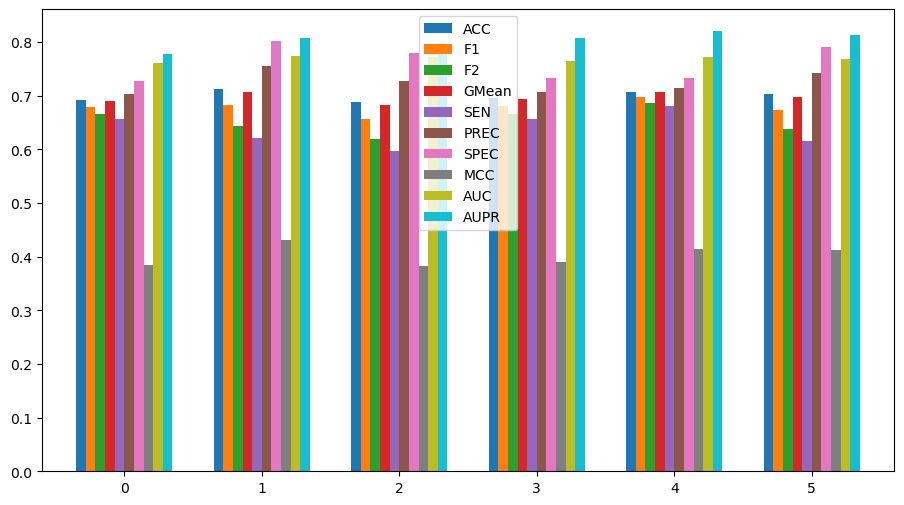

In [10]:
all_eval.plot.bar(figsize=(11,6),rot=0,width = 0.7,grid = False)